In [25]:
import sys
from pathlib import Path

# Ensure project root is on the Python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Step 1: Load overall Phoenix results

Resolves the latest evaluation artifact set from `data/evaluation/results/`, merges answer metrics, document-relevance scores, and raw runner records into a single `row_metrics_df`, and computes the `composite_score` column used by all subsequent cells.

In [26]:
import json
import logging
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.style as mstyle
import numpy as np
import pandas as pd
import seaborn as sns
import structlog

from sources.config import config as app_config

mstyle.use("seaborn-v0_8-whitegrid")

structlog.configure(
    wrapper_class=structlog.make_filtering_bound_logger(logging.INFO),
)
logger = structlog.get_logger(__name__)

# Per-architecture color palette aligned with the thesis TikZ palette
ARCH_ORDER = [
    "deterministic",
    "planner_executor",
    "router_specialist",
    "blackboard",
    "hierarchical",
    "react",
]
ARCH_COLORS = {
    "deterministic": "#5B4FA8",
    "planner_executor": "#2B9BA0",
    "router_specialist": "#8B6DC8",
    "blackboard": "#C07840",
    "hierarchical": "#3A7DB5",
    "react": "#A84848",
}
ARCH_PALETTE = [ARCH_COLORS.get(a, "#888888") for a in ARCH_ORDER]

TITLE_FONT = {"fontsize": 14, "fontweight": "bold", "pad": 14}
LABEL_FONT = {"fontsize": 12}
TICK_FONT = 11
HEATMAP_CMAP = "BuPu"


def _arch_color_list(pattern_series: pd.Series) -> list:
    """Return per-row color list aligned with ARCH_COLORS."""
    return [ARCH_COLORS.get(p, "#888888") for p in pattern_series]


ARTIFACT_PREFIX = "overall"
PHOENIX_SCORE_COLS = [
    *app_config.evaluation.answer_score_cols,
    *app_config.evaluation.document_score_cols,
    *app_config.evaluation.tool_score_cols,
]
OPERATIONS_COLS = list(app_config.evaluation.metric_cols)

GROUP_DIMENSION_ALIASES = {
    "product": ["product", "product_category", "kategoria_produktu"],
    "firma": ["firma", "company", "insurer", "towarzystwo", "provider"],
    "difficulty": [
        "difficulty",
        "question_difficulty",
        "stopien_trudnosci",
        "poziom_trudnosci",
    ],
}

RESULTS_DIR = app_config.paths.results_dir
latest_summary = sorted(
    RESULTS_DIR.glob(f"{ARTIFACT_PREFIX}_summary_*.csv"), reverse=True
)[0]
RUN_ID = latest_summary.stem.replace(f"{ARTIFACT_PREFIX}_summary_", "")

phoenix_summary_df = pd.read_csv(latest_summary)
answer_metric_df = pd.read_csv(
    RESULTS_DIR / f"{ARTIFACT_PREFIX}_answer_metrics_{RUN_ID}.csv"
)
document_metric_df = pd.read_csv(
    RESULTS_DIR / f"{ARTIFACT_PREFIX}_document_relevance_{RUN_ID}.csv"
)

with (RESULTS_DIR / f"runner_results_{RUN_ID}.jsonl").open(
    "r", encoding="utf-8"
) as _fh:
    raw_records = [json.loads(line) for line in _fh if line.strip()]

results_df = pd.DataFrame(raw_records).reset_index().rename(columns={"index": "row_id"})

answer_text = pd.Series(index=results_df.index, data="", dtype=object)
for _col in ["answer_body", "answer_with_references", "answer"]:
    if _col in results_df.columns:
        answer_text = answer_text.where(
            answer_text.astype(str).str.strip().ne(""),
            results_df[_col].fillna(""),
        )
results_df["answer_text"] = answer_text.fillna("")

answer_merge_cols = [
    "row_id",
    "pattern_name",
    *[c for c in answer_metric_df.columns if c.startswith("phoenix_")],
]
row_metrics_df = results_df.merge(
    answer_metric_df[answer_merge_cols], on=["row_id", "pattern_name"], how="left"
)

document_score_cols = [
    c
    for c in app_config.evaluation.document_score_cols
    if c in document_metric_df.columns
]
document_agg = document_metric_df.groupby(["row_id", "pattern_name"], as_index=False)[
    document_score_cols
].mean()
row_metrics_df = row_metrics_df.merge(
    document_agg, on=["row_id", "pattern_name"], how="left"
)

available_phoenix_scores = [
    c for c in PHOENIX_SCORE_COLS if c in row_metrics_df.columns
]

for _col in [*OPERATIONS_COLS, *available_phoenix_scores]:
    if _col in row_metrics_df.columns:
        row_metrics_df[_col] = pd.to_numeric(row_metrics_df[_col], errors="coerce")

row_metrics_df["composite_score"] = row_metrics_df[available_phoenix_scores].mean(
    axis=1, skipna=True
)

resolved_grouping_columns = {}
for _name, _candidates in GROUP_DIMENSION_ALIASES.items():
    _sel = next(
        (
            c
            for c in _candidates
            if c in row_metrics_df.columns and row_metrics_df[c].notna().any()
        ),
        None,
    )
    if _sel:
        resolved_grouping_columns[_name] = _sel

logger.info(
    "overall_evaluation_artifacts_loaded",
    run_id=RUN_ID,
    results_rows=len(results_df),
    row_metrics_rows=len(row_metrics_df),
    phoenix_score_cols=available_phoenix_scores,
    grouping_columns=resolved_grouping_columns,
)

2026-05-16 18:09:51 [info     ] overall_evaluation_artifacts_loaded grouping_columns={'product': 'product', 'firma': 'company', 'difficulty': 'difficulty'} phoenix_score_cols=['phoenix_faithfulness_score', 'phoenix_conciseness_score', 'phoenix_correctness_score', 'phoenix_document_relevance_score'] results_rows=540 row_metrics_rows=540 run_id=20260313_200511


## Step 2: Answer quality overview

Mean Phoenix scores per architecture broken down by metric (grouped bar chart) and a score matrix (heatmap). Metrics: faithfulness, conciseness, correctness, and document relevance.

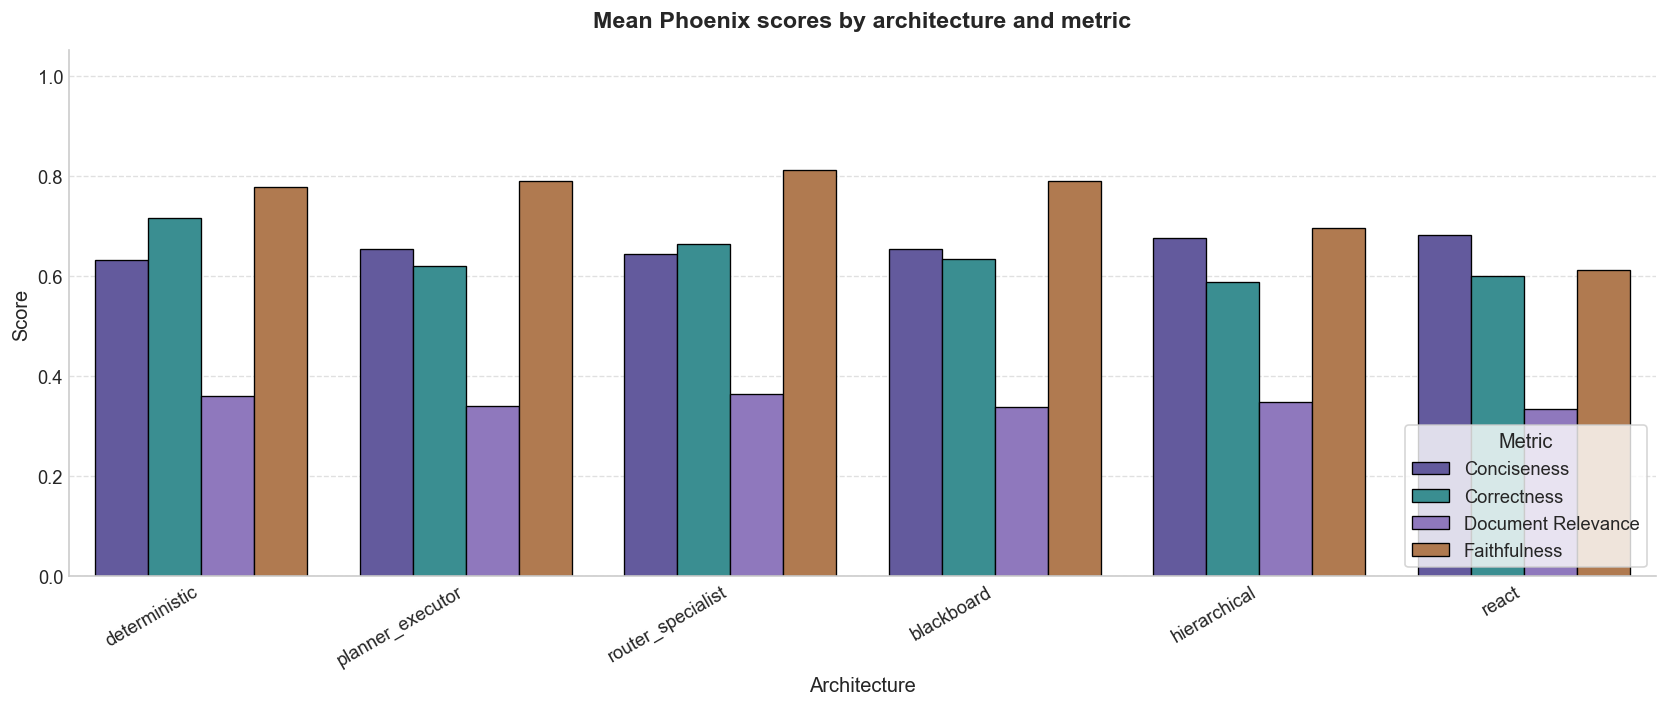

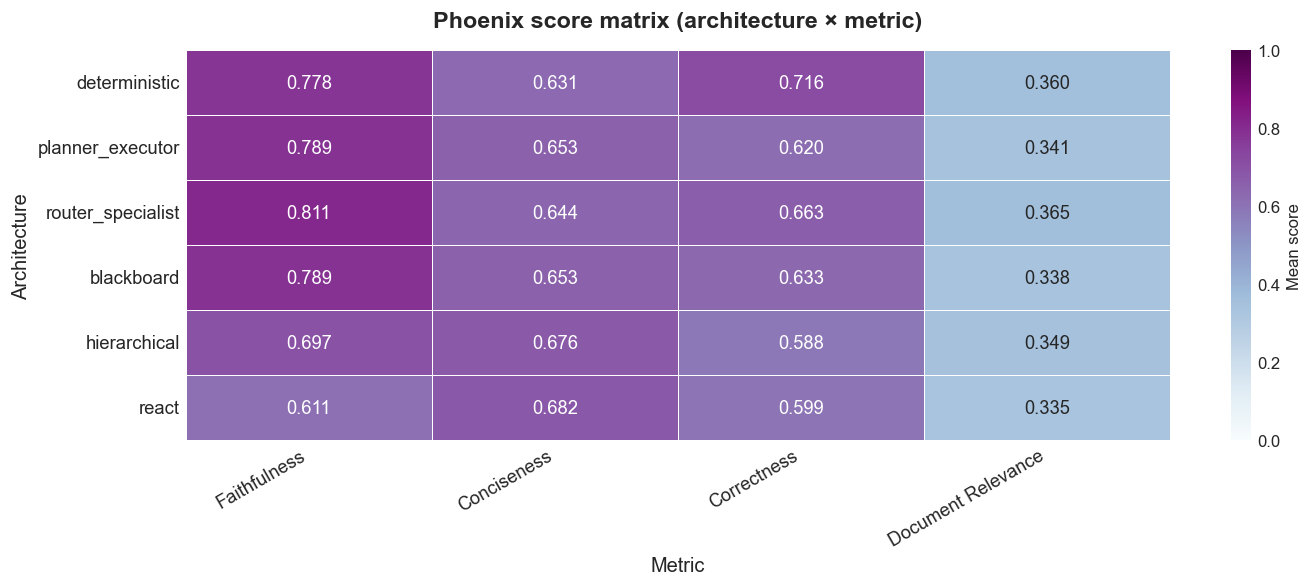

In [27]:
_phoenix_means = (
    row_metrics_df.groupby("pattern_name")[available_phoenix_scores]
    .mean()
    .reset_index()
)
_phoenix_melted = _phoenix_means.melt(
    id_vars="pattern_name", var_name="Metric", value_name="Score"
)
_phoenix_melted["Metric"] = (
    _phoenix_melted["Metric"]
    .str.replace("phoenix_", "", regex=False)
    .str.replace("_score", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)
_metric_order = sorted(_phoenix_melted["Metric"].unique())
_arch_order_present = [
    a for a in ARCH_ORDER if a in _phoenix_means["pattern_name"].values
]

_metric_palette = {
    m: c
    for m, c in zip(
        _metric_order,
        ["#5B4FA8", "#2B9BA0", "#8B6DC8", "#C07840", "#3A7DB5"],
    )
}

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
sns.barplot(
    data=_phoenix_melted,
    x="pattern_name",
    y="Score",
    hue="Metric",
    hue_order=_metric_order,
    order=_arch_order_present,
    palette=_metric_palette,
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_title("Mean Phoenix scores by architecture and metric", **TITLE_FONT)
ax.set_ylabel("Score", **LABEL_FONT)
ax.set_xlabel("Architecture", **LABEL_FONT)
ax.set_ylim(0, 1.05)
ax.legend(
    title="Metric",
    loc="lower right",
    fontsize=TICK_FONT,
    title_fontsize=LABEL_FONT["fontsize"],
    frameon=True,
)
plt.xticks(rotation=30, ha="right", fontsize=TICK_FONT)
plt.yticks(fontsize=TICK_FONT)
plt.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

_heatmap_data = (
    row_metrics_df.groupby("pattern_name")[available_phoenix_scores]
    .mean()
    .reindex(_arch_order_present)
)
_heatmap_data.columns = [
    c.replace("phoenix_", "").replace("_score", "").replace("_", " ").title()
    for c in _heatmap_data.columns
]

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
sns.heatmap(
    _heatmap_data,
    annot=True,
    fmt=".3f",
    cmap=HEATMAP_CMAP,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean score"},
    annot_kws={"fontsize": TICK_FONT},
)
ax.set_title("Phoenix score matrix (architecture × metric)", **TITLE_FONT)
ax.set_ylabel("Architecture", **LABEL_FONT)
ax.set_xlabel("Metric", **LABEL_FONT)
plt.xticks(rotation=30, ha="right", fontsize=TICK_FONT)
plt.yticks(rotation=0, fontsize=TICK_FONT)
plt.tight_layout()
plt.show()

## Step 3: Quality profile

A radar chart showing the multi-dimensional quality profile of each architecture on a single polar plot. It makes it immediately clear which architectures produce flat (balanced) scores and which dominate one metric at the expense of others.

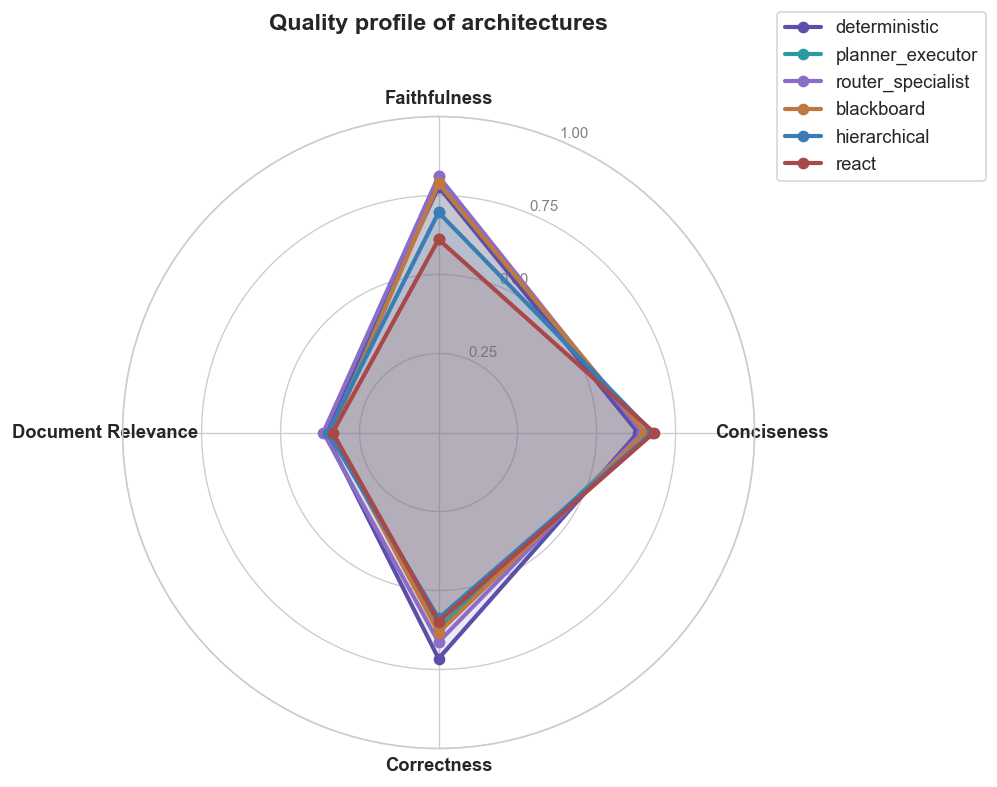

In [28]:
from math import pi

_radar_means = row_metrics_df.groupby("pattern_name")[available_phoenix_scores].mean()
_radar_patterns = [a for a in ARCH_ORDER if a in _radar_means.index]
_categories = [
    m.replace("phoenix_", "").replace("_score", "").replace("_", " ").title()
    for m in available_phoenix_scores
]
_N = len(_categories)
_angles = [i / _N * 2 * pi for i in range(_N)] + [0]  # close polygon

fig = plt.figure(figsize=(9, 9), dpi=120)
ax_polar = fig.add_subplot(111, projection="polar")
ax_polar.set_theta_offset(pi / 2)
ax_polar.set_theta_direction(-1)
ax_polar.set_xticks(_angles[:-1])
ax_polar.set_xticklabels(_categories, size=TICK_FONT, fontweight="bold")
ax_polar.set_ylim(0, 1)
ax_polar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_polar.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], size=9, color="grey")

for _pattern in _radar_patterns:
    _vals = _radar_means.loc[_pattern].tolist() + [_radar_means.loc[_pattern].iloc[0]]
    _col = ARCH_COLORS.get(_pattern, "#888888")
    ax_polar.plot(_angles, _vals, "o-", linewidth=2.5, label=_pattern, color=_col)
    ax_polar.fill(_angles, _vals, alpha=0.12, color=_col)

ax_polar.set_title("Quality profile of architectures", y=1.10, **TITLE_FONT)
ax_polar.legend(
    loc="upper right", bbox_to_anchor=(1.38, 1.18), fontsize=TICK_FONT, frameon=True
)
plt.tight_layout()
plt.show()

## Step 4: Operational metrics

Response latency (box plot, ms) and error rate per architecture (bar chart) in a single panel. Latency is measured from the first tool call to the final answer.

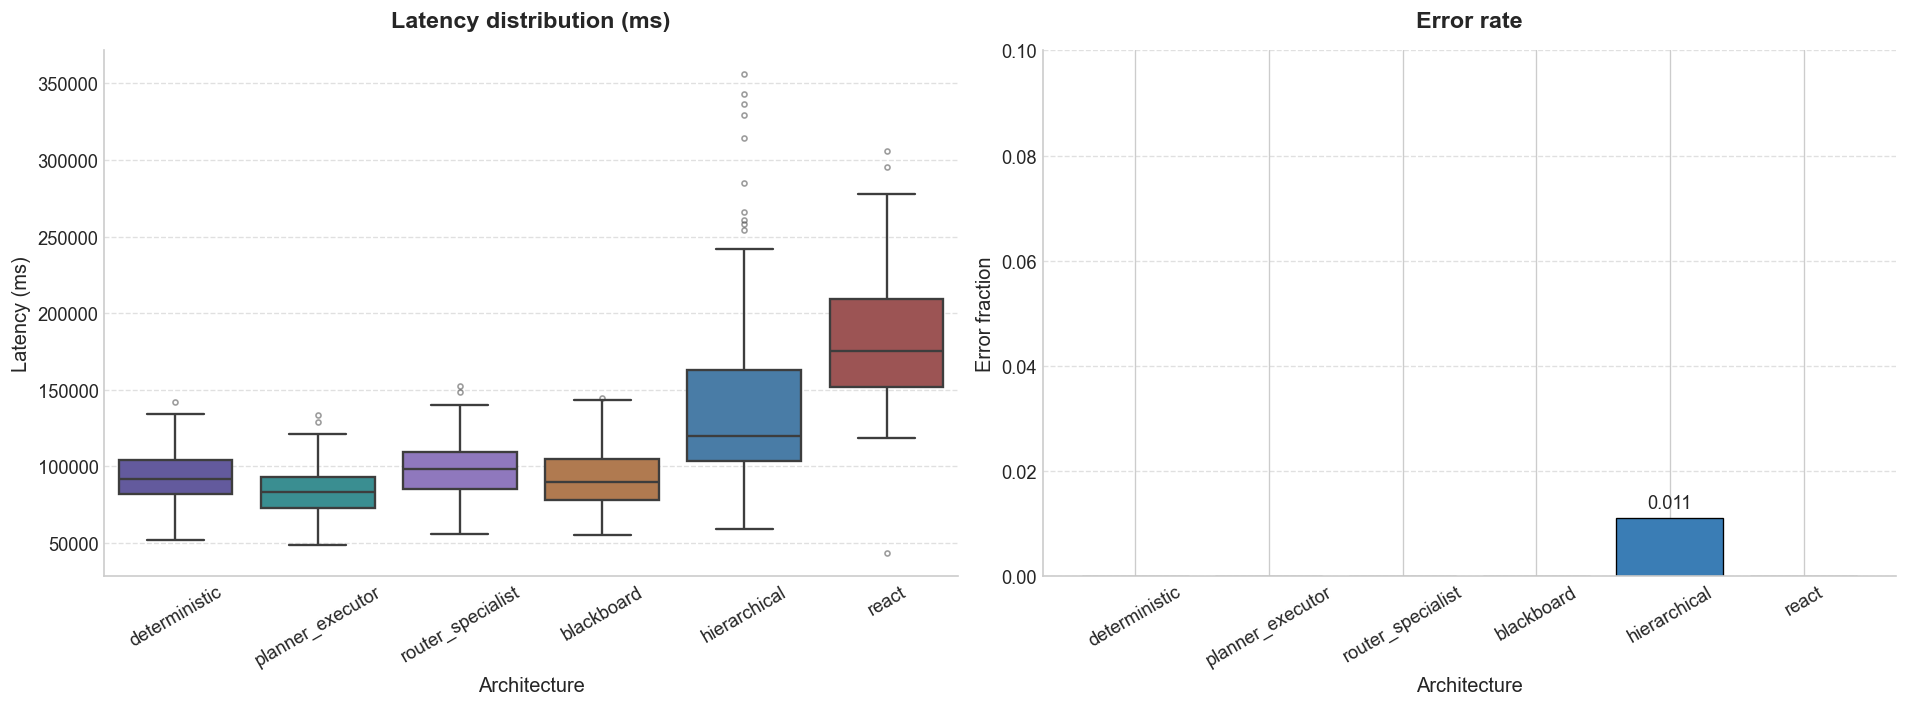

In [29]:
_arch_order_present = [
    a for a in ARCH_ORDER if a in row_metrics_df["pattern_name"].unique()
]
_box_palette = {a: ARCH_COLORS.get(a, "#888888") for a in _arch_order_present}

fig, (ax_lat, ax_err) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

sns.boxplot(
    data=row_metrics_df,
    x="pattern_name",
    y="latency_ms",
    order=_arch_order_present,
    palette=_box_palette,
    ax=ax_lat,
    linewidth=1.4,
    fliersize=3,
    flierprops={"alpha": 0.5},
)
ax_lat.set_title("Latency distribution (ms)", **TITLE_FONT)
ax_lat.set_xlabel("Architecture", **LABEL_FONT)
ax_lat.set_ylabel("Latency (ms)", **LABEL_FONT)
ax_lat.tick_params(axis="x", rotation=30, labelsize=TICK_FONT)
ax_lat.tick_params(axis="y", labelsize=TICK_FONT)
ax_lat.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
ax_lat.set_axisbelow(True)
sns.despine(ax=ax_lat)

_error_df = (
    row_metrics_df.groupby("pattern_name")["error_flag"]
    .mean()
    .reindex(_arch_order_present)
    .reset_index()
)
_bar_colors = _arch_color_list(_error_df["pattern_name"])
_bars = ax_err.bar(
    _error_df["pattern_name"],
    _error_df["error_flag"],
    color=_bar_colors,
    edgecolor="black",
    linewidth=0.8,
)
for _bar, _val in zip(_bars, _error_df["error_flag"]):
    if _val > 0:
        ax_err.text(
            _bar.get_x() + _bar.get_width() / 2,
            _val + 0.002,
            f"{_val:.3f}",
            ha="center",
            fontsize=TICK_FONT,
        )
ax_err.set_title("Error rate", **TITLE_FONT)
ax_err.set_xlabel("Architecture", **LABEL_FONT)
ax_err.set_ylabel("Error fraction", **LABEL_FONT)
ax_err.set_ylim(0, max(_error_df["error_flag"].max() * 1.4, 0.1))
ax_err.tick_params(axis="x", rotation=30, labelsize=TICK_FONT)
ax_err.tick_params(axis="y", labelsize=TICK_FONT)
ax_err.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
ax_err.set_axisbelow(True)
sns.despine(ax=ax_err)

plt.tight_layout()
plt.show()

## Step 5: Latency vs. quality

Scatter plot comparing mean latency against composite Phoenix score for each architecture. Bubble size is proportional to mean run cost (USD); dashed lines mark the median for each axis.

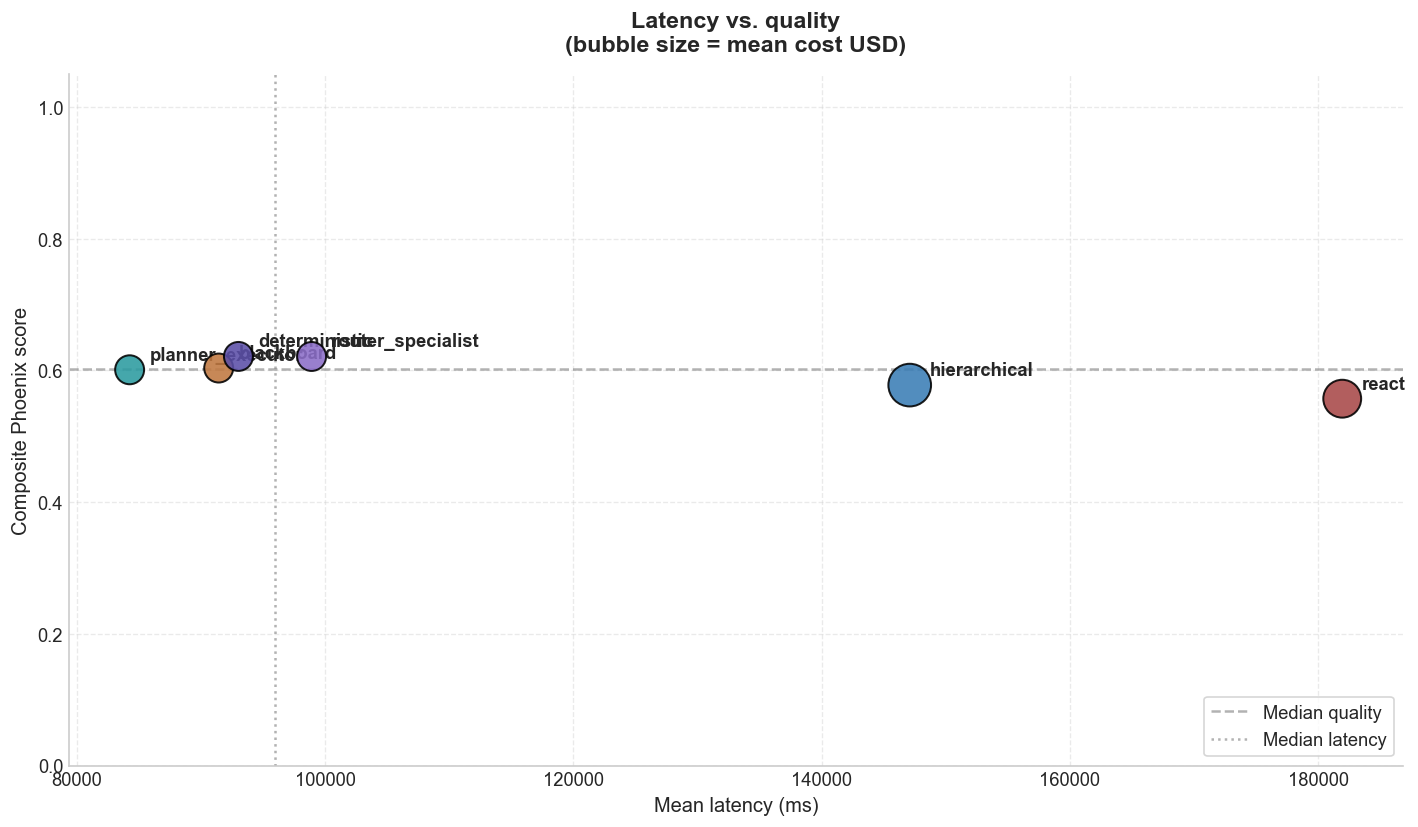

In [30]:
_agg = row_metrics_df.groupby("pattern_name").agg(
    mean_latency=("latency_ms", "mean"),
    completion_rate=("completion_flag", "mean"),
)
_agg["composite_score"] = (
    row_metrics_df.groupby("pattern_name")[available_phoenix_scores].mean().mean(axis=1)
)
if "estimated_total_cost_usd" in row_metrics_df.columns:
    _agg["mean_cost"] = row_metrics_df.groupby("pattern_name")[
        "estimated_total_cost_usd"
    ].mean()
else:
    _agg["mean_cost"] = 0.0

_bubble_sizes = 300 + 5000 * _agg["mean_cost"].fillna(0)
_point_colors = [ARCH_COLORS.get(p, "#888888") for p in _agg.index]

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)
_sc = ax.scatter(
    _agg["mean_latency"],
    _agg["composite_score"],
    s=_bubble_sizes,
    c=_point_colors,
    edgecolors="black",
    linewidth=1.2,
    alpha=0.88,
    zorder=5,
)
for _pattern, _row in _agg.iterrows():
    ax.annotate(
        str(_pattern),
        (_row["mean_latency"], _row["composite_score"]),
        textcoords="offset points",
        xytext=(12, 6),
        fontsize=TICK_FONT,
        fontweight="bold",
    )
ax.axhline(
    _agg["composite_score"].median(),
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="Median quality",
    zorder=1,
)
ax.axvline(
    _agg["mean_latency"].median(),
    color="gray",
    linestyle=":",
    alpha=0.6,
    label="Median latency",
    zorder=1,
)
ax.set_xlabel("Mean latency (ms)", **LABEL_FONT)
ax.set_ylabel("Composite Phoenix score", **LABEL_FONT)
ax.set_title("Latency vs. quality\n(bubble size = mean cost USD)", **TITLE_FONT)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=TICK_FONT, loc="lower right", frameon=True)
ax.tick_params(labelsize=TICK_FONT)
plt.grid(linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

## Step 6: Architecture ranking

Horizontal bar chart ranking architectures by composite Phoenix score (unweighted mean of faithfulness, conciseness, correctness, and document relevance). Values are printed on the bars for precise comparison.

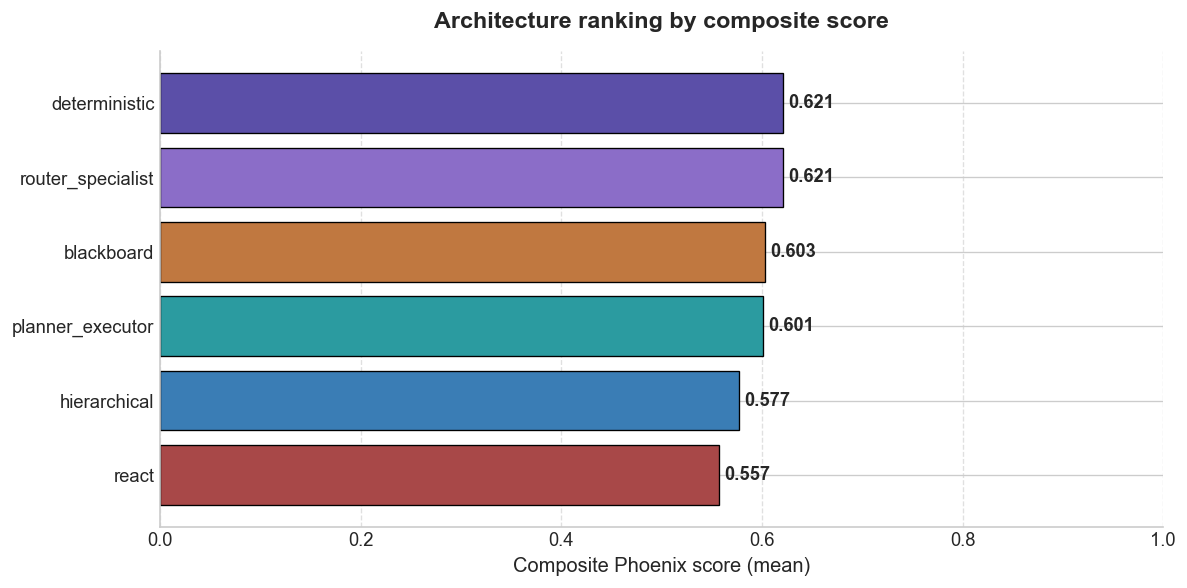

In [31]:
_ranking_df = (
    row_metrics_df.groupby("pattern_name")[available_phoenix_scores]
    .mean()
    .assign(composite=lambda d: d.mean(axis=1))
    .sort_values("composite", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
_bars = ax.barh(
    _ranking_df["pattern_name"],
    _ranking_df["composite"],
    color=_arch_color_list(_ranking_df["pattern_name"]),
    edgecolor="black",
    linewidth=0.8,
)
for _bar, _val in zip(_bars, _ranking_df["composite"]):
    ax.text(
        _val + 0.005,
        _bar.get_y() + _bar.get_height() / 2,
        f"{_val:.3f}",
        va="center",
        fontsize=TICK_FONT,
        fontweight="bold",
    )
ax.set_xlim(0, 1)
ax.set_xlabel("Composite Phoenix score (mean)", **LABEL_FONT)
ax.set_title("Architecture ranking by composite score", **TITLE_FONT)
ax.tick_params(axis="both", labelsize=TICK_FONT)
ax.grid(axis="x", linestyle="--", alpha=0.6, zorder=0)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

## Step 7: Segmentation analysis

Composite Phoenix score broken down across three business dimensions: product category, insurance company, and question difficulty. For each dimension: a grouped bar chart (architecture × dimension value) and a heatmap.

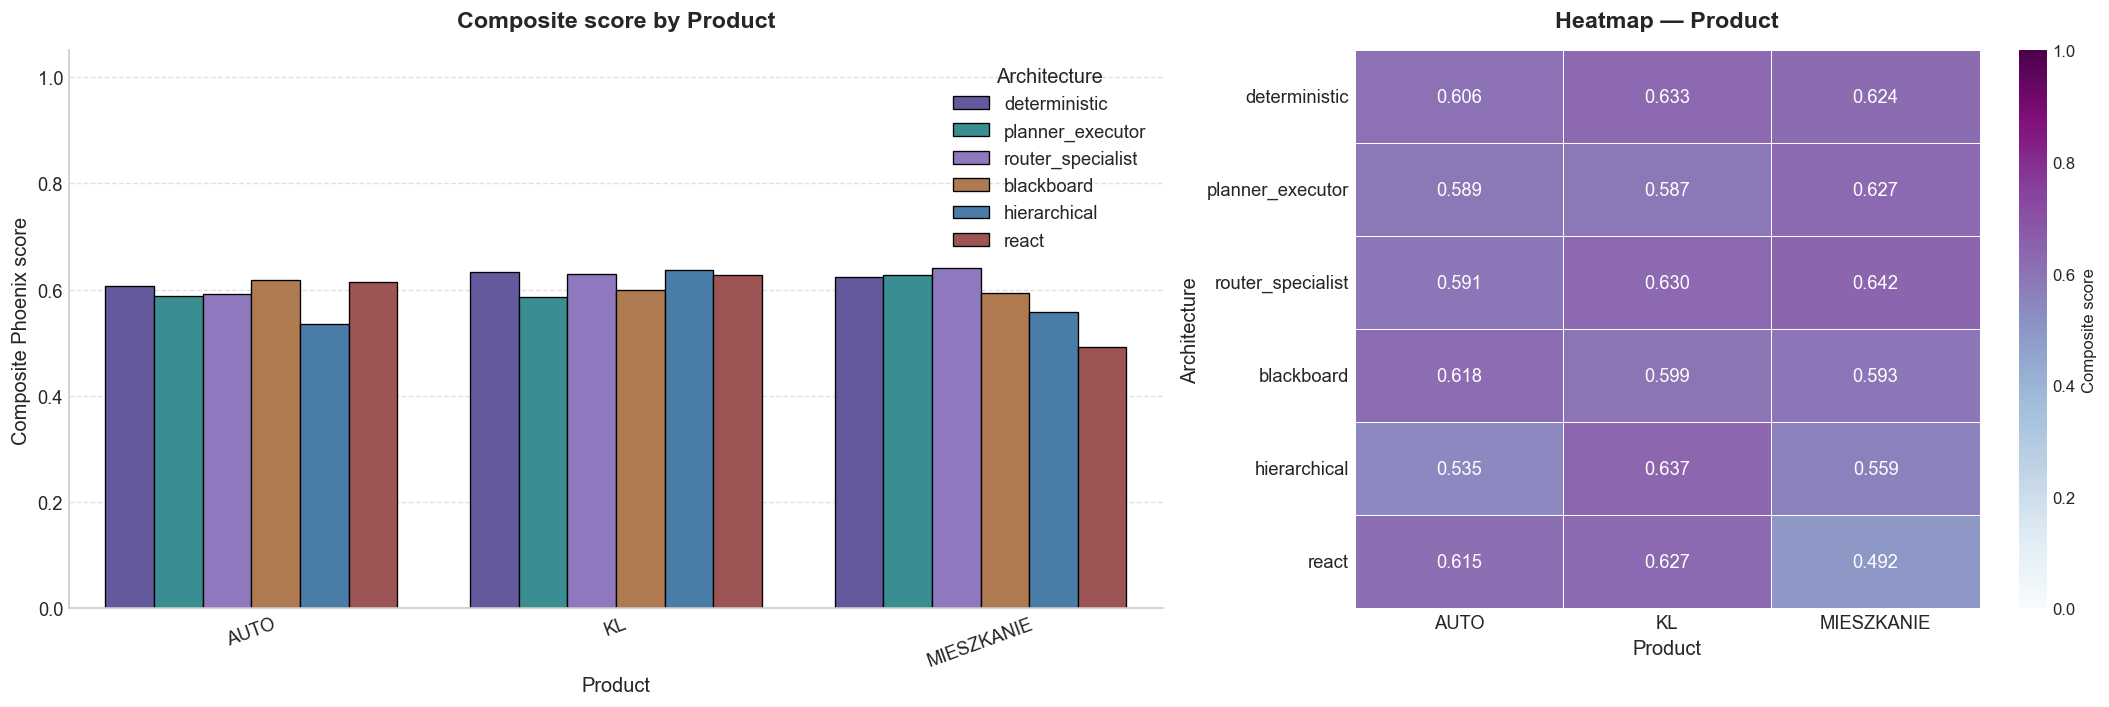

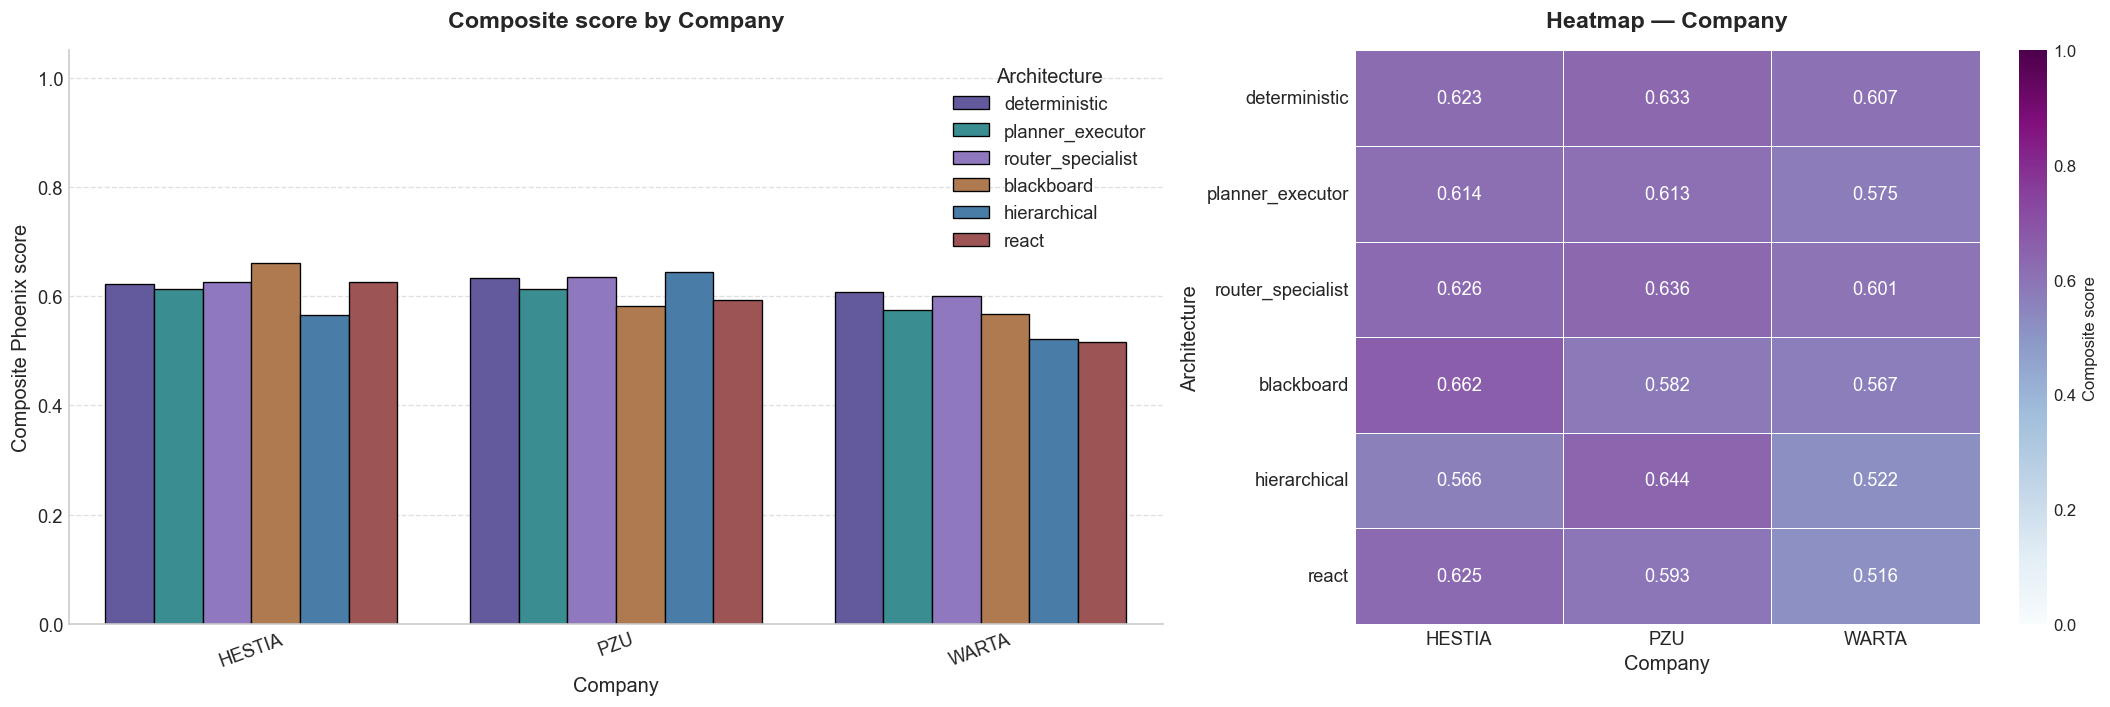

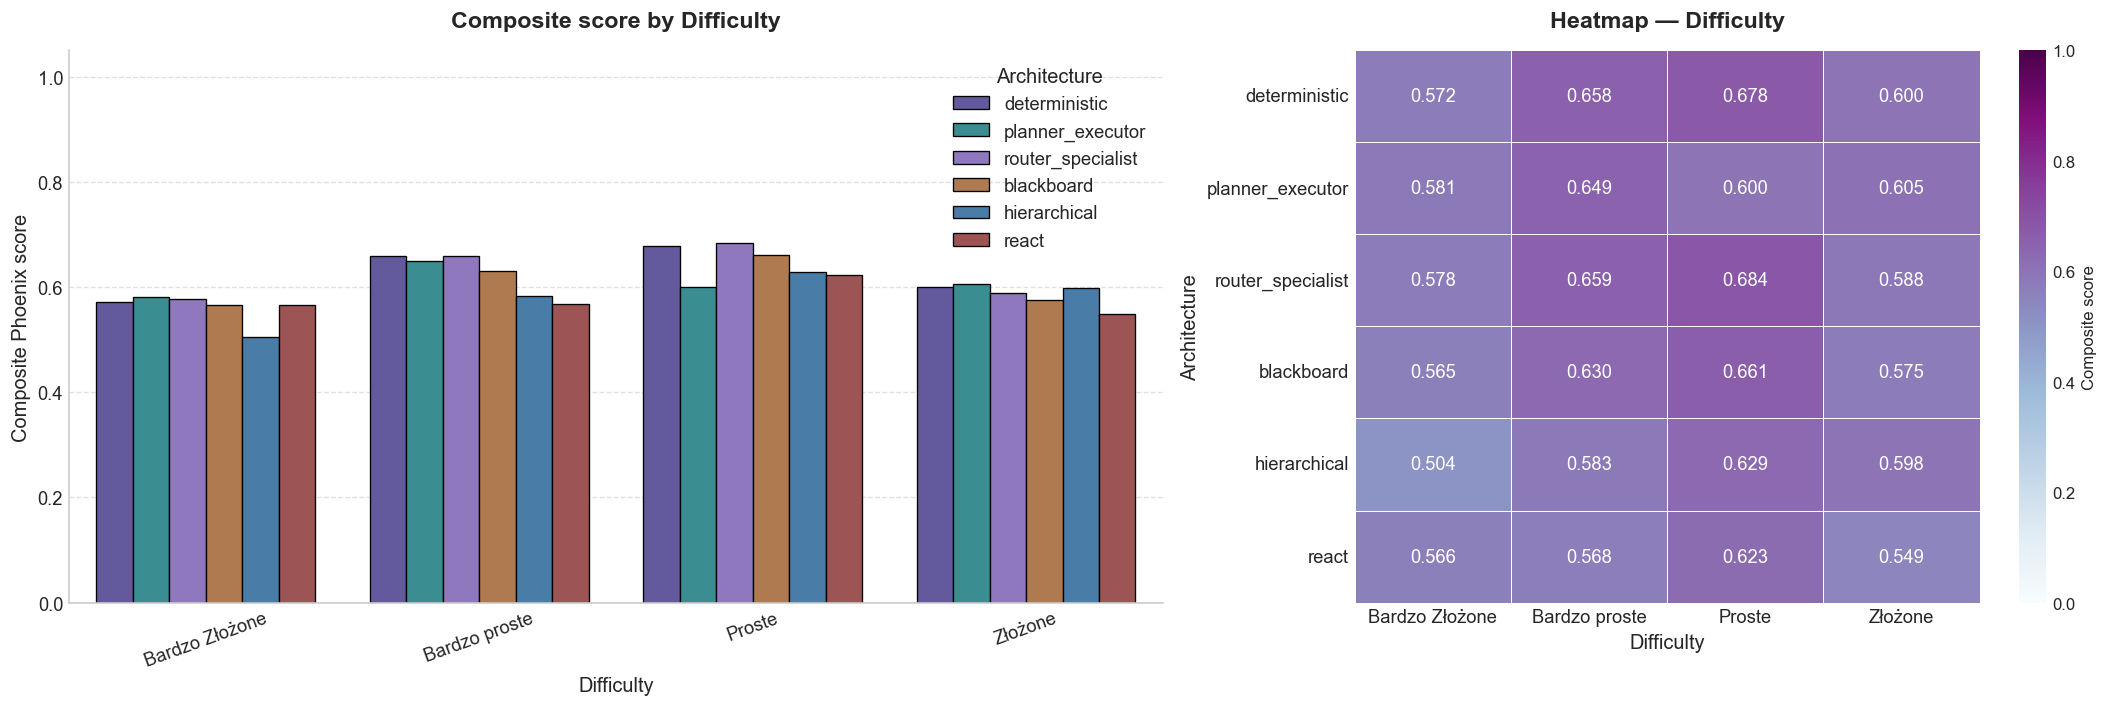

In [32]:
_GROUPED_METRIC = "composite_score"
_dim_labels = {"product": "Product", "firma": "Company", "difficulty": "Difficulty"}

for _dim_name in ["product", "firma", "difficulty"]:
    if _dim_name not in resolved_grouping_columns:
        logger.warning("segmentation_dimension_missing", dimension=_dim_name)
        continue

    _dim_col = resolved_grouping_columns[_dim_name]
    _src = (
        row_metrics_df[["pattern_name", _dim_col, _GROUPED_METRIC]]
        .copy()
        .dropna(subset=[_dim_col])
    )
    _src[_dim_col] = _src[_dim_col].astype(str).str.strip()
    _src = _src[_src[_dim_col] != ""]
    if _src.empty:
        continue

    _grp = (
        _src.groupby(["pattern_name", _dim_col], as_index=False)[_GROUPED_METRIC]
        .mean()
        .sort_values(["pattern_name", _dim_col])
    )
    _arch_present = [a for a in ARCH_ORDER if a in _grp["pattern_name"].values]
    _dim_vals = sorted(_grp[_dim_col].unique())
    _dim_label = _dim_labels.get(_dim_name, _dim_name.capitalize())

    _hue_palette = {a: ARCH_COLORS.get(a, "#888888") for a in _arch_present}

    fig, (ax_bar, ax_heat) = plt.subplots(
        1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1.4, 1.0]}, dpi=120
    )

    sns.barplot(
        data=_grp,
        x=_dim_col,
        y=_GROUPED_METRIC,
        hue="pattern_name",
        hue_order=_arch_present,
        palette=_hue_palette,
        ax=ax_bar,
        edgecolor="black",
        linewidth=0.8,
        order=_dim_vals,
    )
    ax_bar.set_title(f"Composite score by {_dim_label}", **TITLE_FONT)
    ax_bar.set_xlabel(_dim_label, **LABEL_FONT)
    ax_bar.set_ylabel("Composite Phoenix score", **LABEL_FONT)
    ax_bar.set_ylim(0, 1.05)
    ax_bar.legend(
        title="Architecture", fontsize=TICK_FONT, title_fontsize=LABEL_FONT["fontsize"]
    )
    ax_bar.tick_params(axis="x", rotation=20, labelsize=TICK_FONT)
    ax_bar.tick_params(axis="y", labelsize=TICK_FONT)
    ax_bar.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
    ax_bar.set_axisbelow(True)
    sns.despine(ax=ax_bar)

    _pivot = _grp.pivot(
        index="pattern_name", columns=_dim_col, values=_GROUPED_METRIC
    ).reindex(_arch_present)
    sns.heatmap(
        _pivot,
        annot=True,
        fmt=".3f",
        cmap=HEATMAP_CMAP,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=ax_heat,
        cbar_kws={"label": "Composite score"},
        annot_kws={"fontsize": TICK_FONT},
    )
    ax_heat.set_title(f"Heatmap — {_dim_label}", **TITLE_FONT)
    ax_heat.set_xlabel(_dim_label, **LABEL_FONT)
    ax_heat.set_ylabel("Architecture", **LABEL_FONT)
    ax_heat.tick_params(axis="both", labelsize=TICK_FONT)

    plt.tight_layout()
    plt.show()